Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


/Users/roushan/anaconda3/envs/dl_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 559ms/step - accuracy: 0.6158 - loss: 1.0173 - val_accuracy: 0.7400 - val_loss: 0.5279
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 513ms/step - accuracy: 0.7783 - loss: 0.4936 - val_accuracy: 0.7200 - val_loss: 0.5379
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 508ms/step - accuracy: 0.8522 - loss: 0.4134 - val_accuracy: 0.7600 - val_loss: 0.5573
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 508ms/step - accuracy: 0.8719 - loss: 0.3353 - val_accuracy: 0.8000 - val_loss: 0.5619
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 504ms/step - accuracy: 0.8719 - loss: 0.3146 - val_accuracy: 0.8000 - val_loss: 0.4476
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step - accuracy: 0.9360 - loss: 0.2276 - val_accuracy: 0.8200 - val_loss: 0.5308
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 514ms/step - accuracy: 0.9606 - loss: 0.1297 - val_accuracy: 0.8000 - val_loss: 0.5020
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 528ms/step - accuracy: 0.9754 - loss: 0.0729 - val_accuracy: 0.8200 - val_loss:

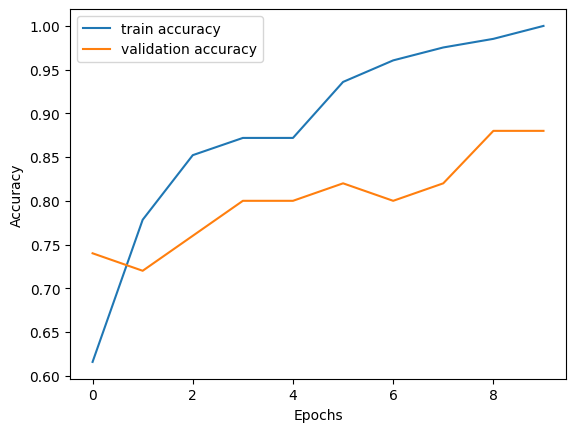

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Image size and batch size
img_size = 224
batch_size = 32

# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_generator = train_datagen.flow_from_directory(
    "Dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_generator = train_datagen.flow_from_directory(
    "Dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Build CNN model
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(2,activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate model
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

# Plot training accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()